# Ball-E (The Leveling Platform) - MIMO Spatial-Temporal Trajectory Planning

## The Engineering Concept

A platform balancing on a sphere represents a highly complex MIMO 
(Multiple-Input Multiple-Output) system. Unlike standard inverted pendulums,
moving in the X-axis induces gyroscopic and dynamic forces that cause 
tilt in the Y-axis. 

Traditional controllers (like decoupled PID) treat the X and Y axes as 
independent, fighting the cross-coupling reactively. 
Here, the PINN acts as a Global Spatial-Temporal Trajectory Planner. 
It learns the exact, continuous sequence of motor torques (T_x, T_y) 
needed to drive the platform to perfect equilibrium, actively utilizing 
the cross-coupling rather than fighting it.

### System Inputs & Outputs:

**Inputs:**
- Time (t) in seconds from 0.0 to T_final

**Outputs (from the Neural Network):**
- x(t), y(t)         : Platform center position relative to the ball
- theta_x(t), theta_y(t) : Platform tilt angles
- T_x(t), T_y(t)     : Actuator torques applied to the platform

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. The Neural Network Architecture

In [2]:
class BallE_MIMO_PINN(nn.Module):
    """
    Physics-Informed Neural Network for Ball-E Leveling Platform
    
    This is a MIMO (Multiple-Input Multiple-Output) system that learns
    the coupled dynamics of a platform balancing on a sphere.
    
    Input:
        t (tensor): Time vector from 0 to T_final
    
    Outputs:
        x, y           : Platform position (m)
        theta_x, theta_y: Platform tilt angles (rad)
        T_x, T_y       : Control torques (N·m)
    """
    def __init__(self):
        super(BallE_MIMO_PINN, self).__init__()
        # Input: time (t)
        # Hidden Layers: 4 layers, 64 neurons each (needed for complex MIMO dynamics)
        # Output: x, y, theta_x, theta_y, T_x, T_y (6 variables)
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 6)
        )

    def forward(self, t):
        out = self.net(t)
        # Extract states and controls
        x       = out[:, 0:1]
        y       = out[:, 1:2]
        theta_x = out[:, 2:3]
        theta_y = out[:, 3:4]
        T_x     = out[:, 4:5]
        T_y     = out[:, 5:6]
        return x, y, theta_x, theta_y, T_x, T_y

# Display network architecture
pinn = BallE_MIMO_PINN()
print("Network Architecture:")
print(pinn)
print(f"\nTotal Parameters: {sum(p.numel() for p in pinn.parameters()):,}")

Network Architecture:
BallE_MIMO_PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=6, bias=True)
  )
)

Total Parameters: 12,998


## 2. Helper Functions

In [3]:
def compute_derivatives(u, t, order=1):
    """
    Computes derivatives of variable u with respect to time t using PyTorch Autograd.
    
    Parameters:
        u: Variable to differentiate
        t: Time variable
        order: Order of derivative (1 for velocity, 2 for acceleration)
    
    Returns:
        du_dt or d2u_dt2: First or second derivative
    """
    du_dt = torch.autograd.grad(
        u, t, 
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]
    
    if order == 1:
        return du_dt
    elif order == 2:
        d2u_dt2 = torch.autograd.grad(
            du_dt, t, 
            grad_outputs=torch.ones_like(du_dt),
            create_graph=True,
            retain_graph=True
        )[0]
        return d2u_dt2

print("Helper functions defined successfully!")

Helper functions defined successfully!


## 3. Physics & Loss Formulation

In [4]:
def pinn_mimo_loss(pinn, t_collocation, initial_states):
    """
    Calculates the total loss combining Physics, Boundary Conditions (Start/End),
    and Control Effort Optimization.
    
    The loss consists of:
    1. Physics residual (enforces the coupled MIMO dynamics)
    2. Initial conditions (ensures trajectory starts from given state)
    3. Target conditions (ensures trajectory ends at equilibrium)
    4. Control effort penalty (encourages energy-efficient control)
    """
    t_collocation.requires_grad = True
    x, y, theta_x, theta_y, T_x, T_y = pinn(t_collocation)

    # Calculate 1st and 2nd derivatives (Velocities and Accelerations)
    x_dot    = compute_derivatives(x, t_collocation, order=1)
    x_ddot   = compute_derivatives(x, t_collocation, order=2)
    
    y_dot    = compute_derivatives(y, t_collocation, order=1)
    y_ddot   = compute_derivatives(y, t_collocation, order=2)
    
    th_x_dot = compute_derivatives(theta_x, t_collocation, order=1)
    th_x_ddot= compute_derivatives(theta_x, t_collocation, order=2)
    
    th_y_dot = compute_derivatives(theta_y, t_collocation, order=1)
    th_y_ddot= compute_derivatives(theta_y, t_collocation, order=2)

    # -------------------------------------------------------------------------
    # 1. THE PHYSICS LOSS (The Dynamic Constraints)
    # -------------------------------------------------------------------------
    # Physical Parameters (Simplified for simulation)
    g = 9.81         # Gravity (m/s^2)
    alpha = 5.0      # Torque-to-acceleration scaling factor
    beta = 2.5       # Gyroscopic cross-coupling coefficient
    
    # Translational dynamics: Tilt causes translation
    # Note: Tilt in Y causes motion in X, Tilt in X causes motion in -Y
    res_x = x_ddot - g * torch.sin(theta_y)
    res_y = y_ddot + g * torch.sin(theta_x)
    
    # Rotational dynamics (MIMO coupled): 
    # Moving one axis induces a gyroscopic reaction (beta * velocity of the other axis)
    res_th_x = th_x_ddot - (alpha * T_x + beta * th_y_dot)
    res_th_y = th_y_ddot - (alpha * T_y - beta * th_x_dot)

    loss_physics = torch.mean(res_x**2 + res_y**2 + res_th_x**2 + res_th_y**2)

    # -------------------------------------------------------------------------
    # 2. THE BOUNDARY CONDITIONS (Start and Target States)
    # -------------------------------------------------------------------------
    # Initial State (t = 0)
    t_start = torch.zeros(1, 1, requires_grad=True)
    x_0, y_0, th_x_0, th_y_0, _, _ = pinn(t_start)
    
    loss_start = (
        (x_0 - initial_states['x'])**2 + 
        (y_0 - initial_states['y'])**2 + 
        (th_x_0 - initial_states['th_x'])**2 + 
        (th_y_0 - initial_states['th_y'])**2
    )
    
    # Initial Velocities must be zero
    v_x_0 = compute_derivatives(x_0, t_start, order=1)
    v_y_0 = compute_derivatives(y_0, t_start, order=1)
    loss_v_start = torch.mean(v_x_0**2 + v_y_0**2)

    # Final State (t = 3.0s) -> Must arrive at dead center (0,0) and flat (0,0)
    t_end = torch.full((1, 1), 3.0, requires_grad=True)
    x_f, y_f, th_x_f, th_y_f, _, _ = pinn(t_end)
    
    loss_end = (x_f**2 + y_f**2 + th_x_f**2 + th_y_f**2)
    
    # Final Velocities must be zero (soft landing)
    v_x_f = compute_derivatives(x_f, t_end, order=1)
    v_y_f = compute_derivatives(y_f, t_end, order=1)
    th_v_x_f = compute_derivatives(th_x_f, t_end, order=1)
    th_v_y_f = compute_derivatives(th_y_f, t_end, order=1)
    loss_v_end = torch.mean(v_x_f**2 + v_y_f**2 + th_v_x_f**2 + th_v_y_f**2)

    # -------------------------------------------------------------------------
    # 3. THE OPTIMAL CONTROL LOSS (Energy Minimization)
    # -------------------------------------------------------------------------
    # Penalize excessive torques to find the most efficient path
    loss_control = torch.mean(T_x**2 + T_y**2) * 0.05 

    # Total Loss Formulation
    total_loss = (
        1.0 * loss_physics + 
        10.0 * loss_start + 
        10.0 * loss_v_start + 
        15.0 * loss_end + 
        15.0 * loss_v_end + 
        loss_control
    )
    
    return total_loss, loss_physics, loss_start, loss_end, loss_control

print("Loss function defined successfully!")

Loss function defined successfully!


## 4. Training the PINN

In [5]:
print("Initializing Ball-E MIMO PINN Controller...")
pinn = BallE_MIMO_PINN()

# Using L-BFGS for fast, accurate convergence on physics problems
optimizer = optim.LBFGS(
    pinn.parameters(), 
    lr=0.1, 
    max_iter=20, 
    tolerance_grad=1e-5, 
    tolerance_change=1e-7, 
    history_size=50
)

# Time domain: 0 to 3.0 seconds
t_collocation = torch.linspace(0, 3.0, 300).view(-1, 1)

# Initial unstable state (Robot is off-center and tilted)
initial_states = {
    'x': 0.15,        # 15cm off center in X
    'y': -0.10,       # -10cm off center in Y
    'th_x': 0.20,     # Tilted ~11.5 degrees
    'th_y': -0.15     # Tilted ~-8.5 degrees
}

print(f"\nInitial Conditions:")
print(f"  Position X: {initial_states['x']*100:.1f} cm")
print(f"  Position Y: {initial_states['y']*100:.1f} cm")
print(f"  Tilt X: {np.degrees(initial_states['th_x']):.1f}°")
print(f"  Tilt Y: {np.degrees(initial_states['th_y']):.1f}°")
print(f"  Target Time: 3.0 seconds")

Initializing Ball-E MIMO PINN Controller...

Initial Conditions:
  Position X: 15.0 cm
  Position Y: -10.0 cm
  Tilt X: 11.5°
  Tilt Y: -8.6°
  Target Time: 3.0 seconds


In [6]:
epochs = 400
loss_history = []

print(f"\nTraining started. Mapping spatial-temporal trajectory to equilibrium...")

def closure():
    optimizer.zero_grad()
    loss, loss_physics, loss_start, loss_end, loss_control = pinn_mimo_loss(pinn, t_collocation, initial_states)
    loss.backward()
    return loss

for epoch in range(epochs):
    loss = optimizer.step(closure)
    loss_history.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d}/{epochs} | Total Loss: {loss.item():.6f}")
        
print("\nTraining Complete! The PINN has discovered the optimal MIMO trajectory.")


Training started. Mapping spatial-temporal trajectory to equilibrium...
Epoch   50/400 | Total Loss: 0.002503
Epoch  100/400 | Total Loss: 0.001237
Epoch  150/400 | Total Loss: 0.001036
Epoch  200/400 | Total Loss: 0.000813
Epoch  250/400 | Total Loss: 0.000797
Epoch  300/400 | Total Loss: 0.000742
Epoch  350/400 | Total Loss: 0.000742
Epoch  400/400 | Total Loss: 0.000742

Training Complete! The PINN has discovered the optimal MIMO trajectory.


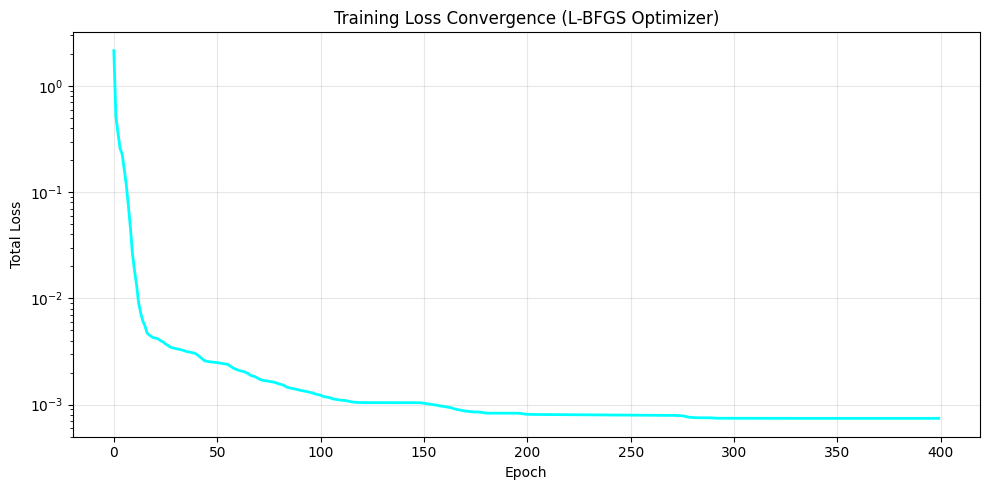

In [7]:
# Plot training loss convergence
plt.figure(figsize=(10, 5))
plt.plot(loss_history, color='cyan', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Training Loss Convergence (L-BFGS Optimizer)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Simulation & Visualization

In [8]:
# Generate time vector for plotting
t_test = torch.linspace(0, 3.0, 300).view(-1, 1)

with torch.no_grad():
    x, y, th_x, th_y, T_x, T_y = pinn(t_test)
    
t_num = t_test.numpy().flatten()
x_num = x.numpy().flatten()
y_num = y.numpy().flatten()
th_x_num = th_x.numpy().flatten()
th_y_num = th_y.numpy().flatten()
Tx_num = T_x.numpy().flatten()
Ty_num = T_y.numpy().flatten()

print("Trajectory Statistics:")
print(f"  Max Position X: {np.max(np.abs(x_num))*100:.2f} cm")
print(f"  Max Position Y: {np.max(np.abs(y_num))*100:.2f} cm")
print(f"  Max Tilt X: {np.degrees(np.max(np.abs(th_x_num))):.2f}°")
print(f"  Max Tilt Y: {np.degrees(np.max(np.abs(th_y_num))):.2f}°")
print(f"  Max Torque X: {np.max(np.abs(Tx_num)):.2f} N·m")
print(f"  Max Torque Y: {np.max(np.abs(Ty_num)):.2f} N·m")

Trajectory Statistics:
  Max Position X: 15.01 cm
  Max Position Y: 24.76 cm
  Max Tilt X: 11.45°
  Max Tilt Y: 8.58°
  Max Torque X: 0.09 N·m
  Max Torque Y: 0.23 N·m


Trajectory plot saved as 'balle_pinn_trajectory.png'


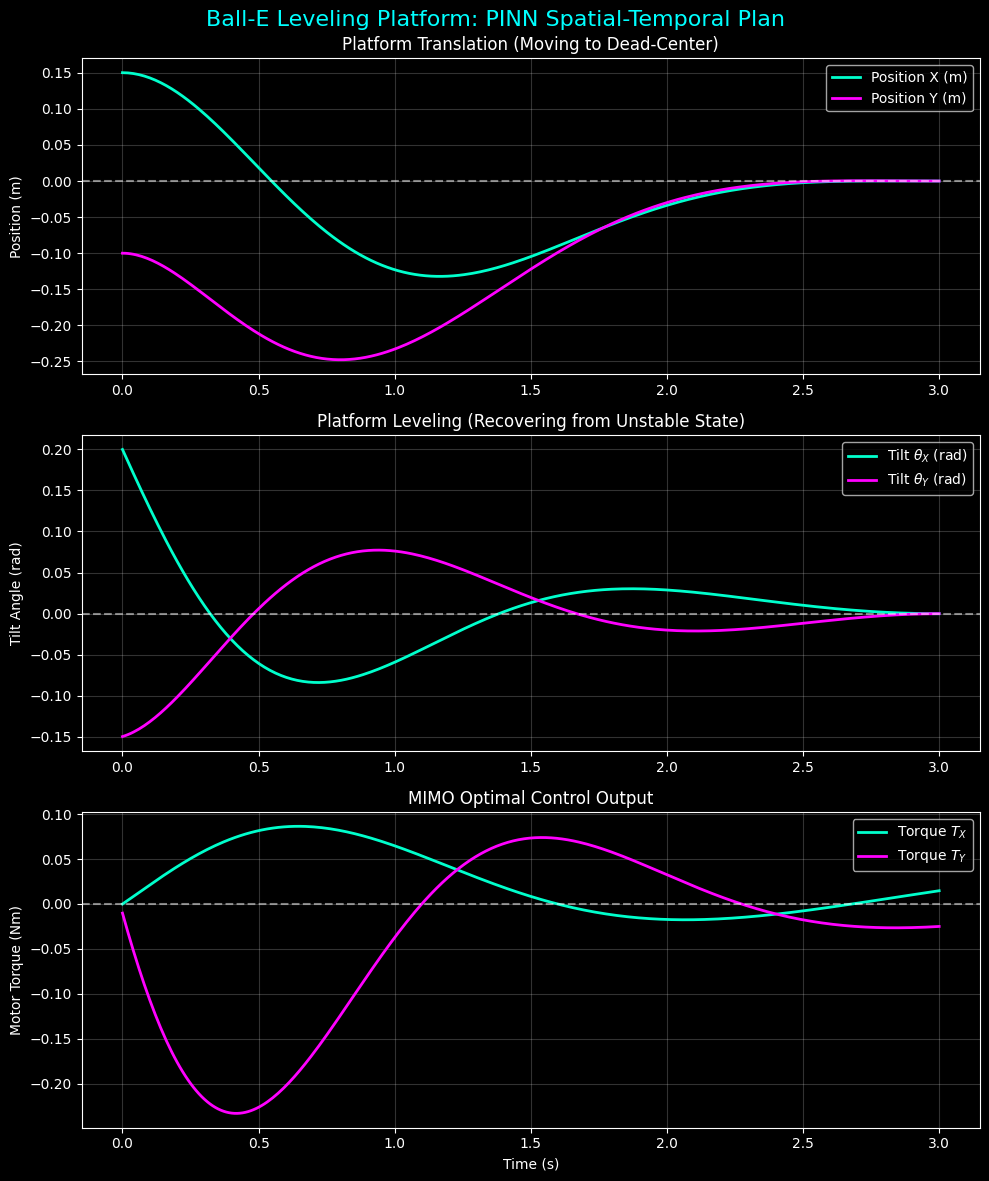

In [9]:
# Create figure
plt.style.use('dark_background')
fig, axs = plt.subplots(3, 1, figsize=(10, 12))
fig.suptitle('Ball-E Leveling Platform: PINN Spatial-Temporal Plan', fontsize=16, color='cyan')

# Plot 1: Positional Trajectory (Convergence to Origin)
axs[0].plot(t_num, x_num, label='Position X (m)', color='#00ffcc', linewidth=2)
axs[0].plot(t_num, y_num, label='Position Y (m)', color='#ff00ff', linewidth=2)
axs[0].axhline(0, color='white', linestyle='--', alpha=0.5)
axs[0].set_ylabel('Position (m)')
axs[0].set_title('Platform Translation (Moving to Dead-Center)')
axs[0].legend()
axs[0].grid(True, alpha=0.2)

# Plot 2: Tilt Angles
axs[1].plot(t_num, th_x_num, label='Tilt $\\theta_X$ (rad)', color='#00ffcc', linewidth=2)
axs[1].plot(t_num, th_y_num, label='Tilt $\\theta_Y$ (rad)', color='#ff00ff', linewidth=2)
axs[1].axhline(0, color='white', linestyle='--', alpha=0.5)
axs[1].set_ylabel('Tilt Angle (rad)')
axs[1].set_title('Platform Leveling (Recovering from Unstable State)')
axs[1].legend()
axs[1].grid(True, alpha=0.2)

# Plot 3: MIMO Control Effort (Decoupled Torques)
axs[2].plot(t_num, Tx_num, label='Torque $T_X$', color='#00ffcc', linewidth=2)
axs[2].plot(t_num, Ty_num, label='Torque $T_Y$', color='#ff00ff', linewidth=2)
axs[2].axhline(0, color='white', linestyle='--', alpha=0.5)
axs[2].set_ylabel('Motor Torque (Nm)')
axs[2].set_xlabel('Time (s)')
axs[2].set_title('MIMO Optimal Control Output')
axs[2].legend()
axs[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('balle_pinn_trajectory.png', dpi=300, bbox_inches='tight')
print("Trajectory plot saved as 'balle_pinn_trajectory.png'")
plt.show()